In [1]:
import numpy as np
import pandas as pd

# Descriptive Analysis for the Numerical Columns

#### Step 1: Load dataset

In [56]:
# pandas library has a read_csv method to help us read csv files/datasets into dataframes
dataset_raw = pd.read_csv("./sales_data_with_discounts.csv")
dataset_raw.head()

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


In [57]:
# can use .dtypes to see all datatypes of new dataframe (inferred by pandas library)
dataset_raw.dtypes

Date                     str
Day                      str
SKU                      str
City                     str
Volume                 int64
BU                       str
Brand                    str
Model                    str
Avg Price              int64
Total Sales Value      int64
Discount Rate (%)    float64
Discount Amount      float64
Net Sales Value      float64
dtype: object

In [4]:
# numerical data will be either int64 or float64
# can use select_dtypes method to return subset of columns that are only numerical data
dataset_numeric = dataset_raw.select_dtypes(include=["float64", "int64"])
dataset_numeric.head()

,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,15,12100,181500,11.654820,21153.498820,160346.501180
1,10,10100,101000,11.560498,11676.102961,89323.897039
2,7,16100,112700,9.456886,10657.910157,102042.089843
3,6,20100,120600,6.935385,8364.074702,112235.925298
4,3,8100,24300,17.995663,4372.946230,19927.053770
...,...,...,...,...,...,...
445,2,1300,2600,15.475687,402.367873,2197.632127
446,6,2600,15600,17.057027,2660.896242,12939.103758
447,2,1600,3200,18.965550,606.897606,2593.102394
448,3,1900,5700,16.793014,957.201826,4742.798174


In [9]:
describe_df = pd.DataFrame(columns=dataset_numeric.columns)
describe_df.loc['mean'] = dataset_numeric.mean()
describe_df.loc['median'] = dataset_numeric.median()
# mode() can return series as it can find multiple values that are same, .iloc[0] will return the first row / a scalar to apply
describe_df.loc['mode'] = dataset_numeric.mode().iloc[0]
describe_df.loc['standard deviation'] = dataset_numeric.std()
describe_df

,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
mean,5.066667,10453.433333,33812.835556,15.155242,3346.499424,30466.336131
median,4.000000,1450.000000,5700.000000,16.577766,988.933733,4677.788059
mode,3.000000,400.000000,24300.000000,5.007822,69.177942,326.974801
standard deviation,4.231602,18079.904840,50535.074173,4.220602,4509.902963,46358.656624


## Descriptive Analytics Interpretation

#### Volume:
- Mean (5.07), median (4), and mode (3) are all close together, suggesting distribution close to normal
- Standard deviation (4.23) is small relative to the range, indicating most daily volumes stay reasonably close to the mean
- The most frequent (mode) sales volume on any given day is 3

#### Avg Price:
- Mean (10,453) is roughly 7 times the median (1,450), indicating strong positive skew (right-tail). Far from a normal distribution
- Standard deviation (18,080) is larger than the mean itself, meaning prices vary wildly from the mean
- The most frequent / mode (400) is significantly lower than the mean
- A few models with very large average prices are reason behind the large mean and difference between mean and median

#### Total Sales Value:
- Mean (33,813) is roughly 6 times the median (5,700), indicating strong positive skew (right-tail)
- Standard deviation (50,535) is much larger than the mean. Far from normal distribution
    - There must be a positive skew (right-tail) of few large sales
- A few large total sales on some days are reason behind the large mean and large difference between mean and median

#### Discount Rate (%):
- Mean (15.16) and median (16.58) are close, suggesting a roughly symmetric distribution
- Standard deviation (4.22) is also close to the mean, meaning most discount rates applied are close to the mean
- The most frequent / mode (5.01) is notably lower than both mean and median, suggesting minimum discount possible is close to 5%

#### Discount Amount:
- Mean (3,346) is roughly 3 times the median (989), indicating positive skew (right-tail)
- Standard deviation (4,510) is larger than the mean, meaning discount amounts vary widely from the mean
- The mode (69.18) is very small, showing that most discounts applied are quite low
- A few large discounts on higher-value transactions are reason behind the large mean and large difference between mean and median

#### Net Sales Value:
- Mean (30,466) is roughly 6.5 times the median (4,678), indicating strong positive skew (right-tail)
- Standard deviation (46,359) is larger than the mean, meaning net sales vary widely from the mean
- A few large net sales on some days are reason behind the large mean and difference between mean and median

## Data Visualization
- Objective: To visualize the distribution and relationship of numerical and categorical variables in the dataset

#### Histograms
- Plot histograms for each numerical column
- Analyze distribution (e.g. skewness, presence of outliers) and provide inferences

In [10]:
import matplotlib.pyplot as plt

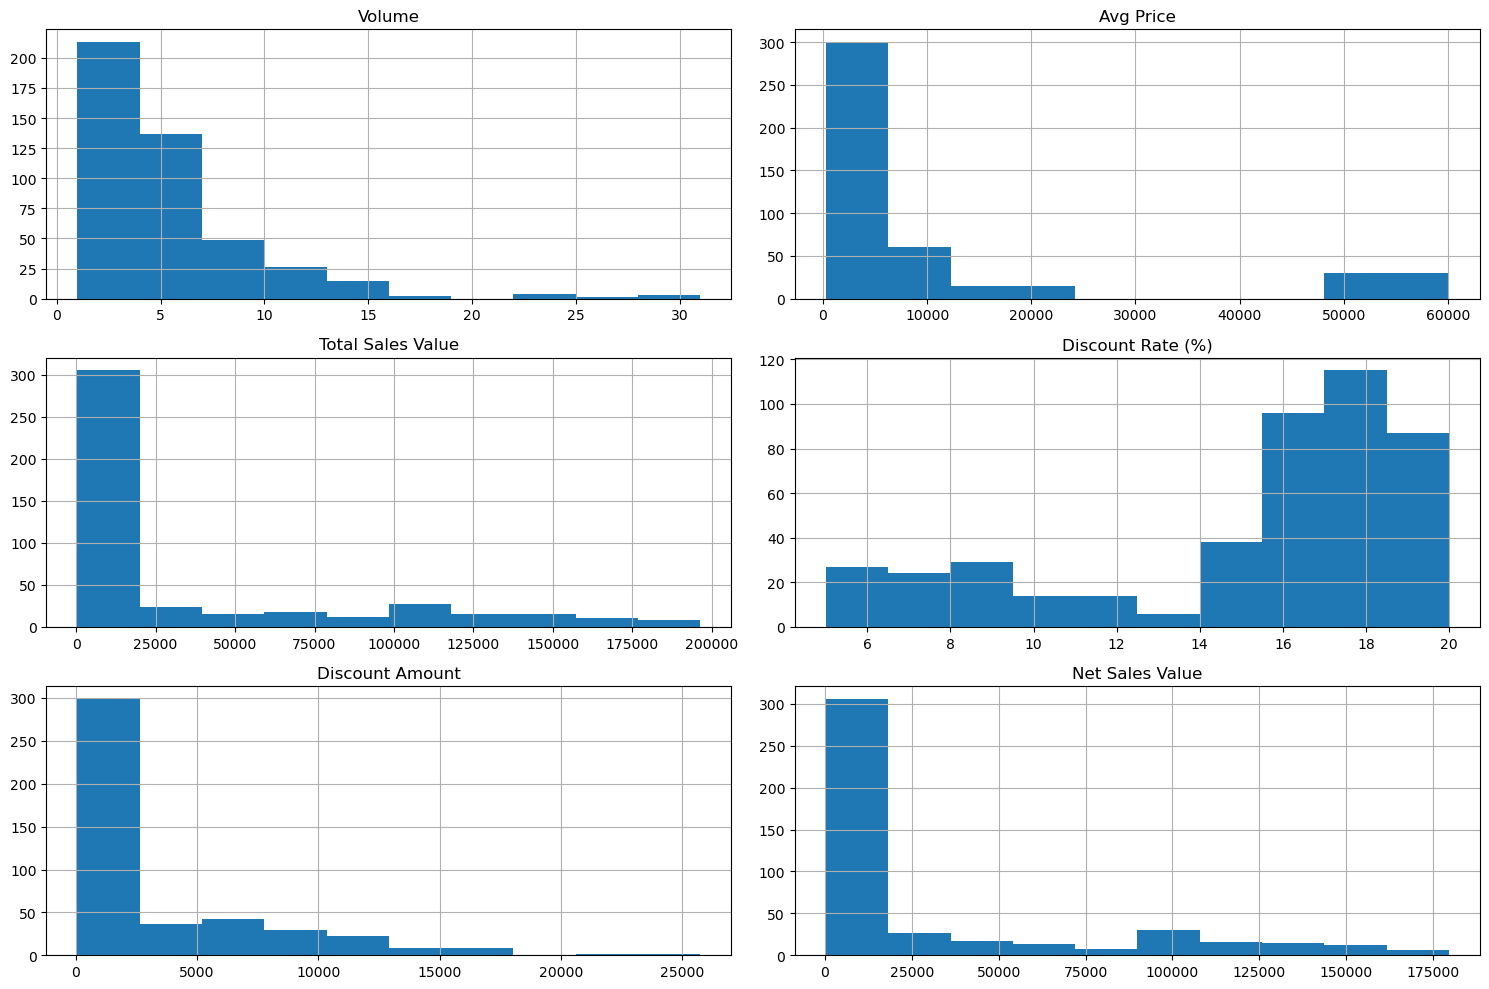

In [55]:
dataset_numeric.hist(figsize=(15, 10), layout=(3, 2))
plt.tight_layout()
plt.show()

## Analysis
- Almost all histograms show positive skew with long right tails
    - With exception of Discount Rate which has a negative skew
- Sales volume has a few outliers that are between 22-30.
    - However most days (335/450) have sales volumes between 0-5. The outliers could be bulk sell orders.
- Total Sales Value and Net Sales Value are almost identical
    - It makes sense if we assume that Net Sales equals Total Sales - Discount Amount. 
- Average Price histogram shows quite a few outliers between 48000-60000, these outliers could be why mean value is much higher than median
- Discount rate has a lot of outliers between 5% and 10%, since most of the discounts are between 14% and 20%
- Discount Amount is positive skew and the vast majority of discounts amounts are small and between 0 - 2500.
    - It is that both 14%-20% discounts and 5-10% discount end up as small amounts that are both in between 0-2500


#### Boxplots

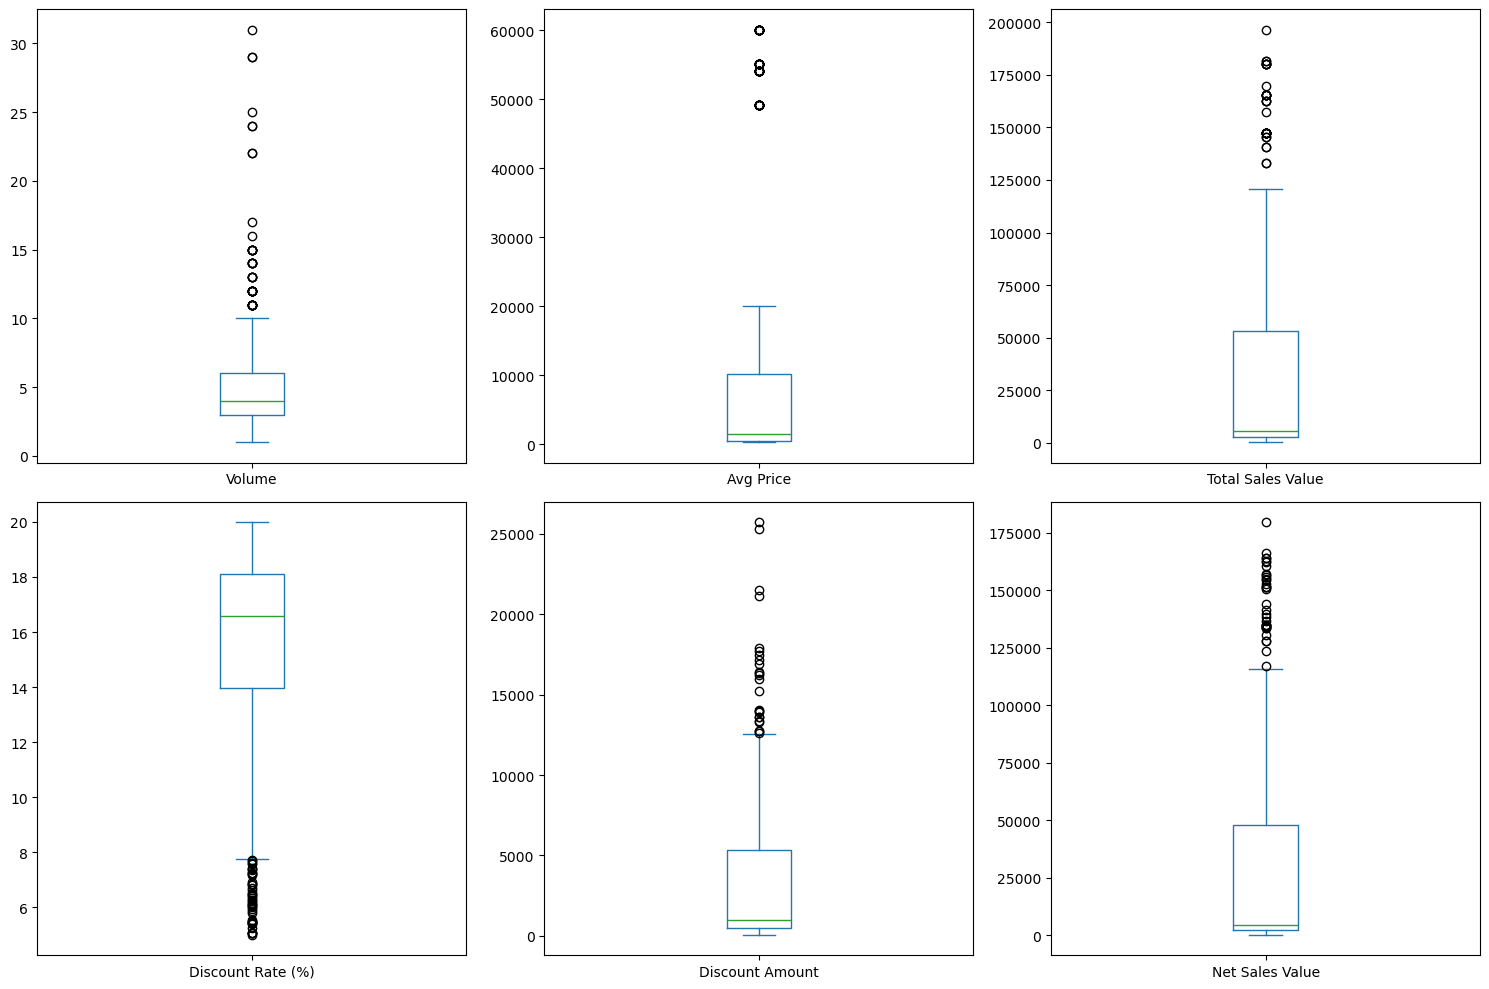

In [38]:
dataset_numeric.plot(kind='box', subplots=True, layout=(2, 3), figsize=(15, 10))
plt.tight_layout()
plt.show()

## Observations
- Average Price, Discount Amount, Total Sales value and Net Sales Value all share a distribution that has a very long right tail (positive skew)
    - for each of those the box plot, the upper quartile range and maximum whiskers are much further from the median than the lower quartile and minimum whisker
        - the median is much closer to the lower quartile range which also confirm that these are positively skewed distributions (long right-tails)
- Sales Volume box plot is the most symmetrical suggesting it is the distribution with least skew.
    - However, there are many extreme and varied outliers, some between 20-30, when the box sits between 3-6
- Discount Rate is the only one that has a negative skew, the median is closer to the upper quartile range. The minimum whisker is much further away from the box than the maximum whisker.
    - most of the outliers are below the lower quartile range
    - This is in line with its histogram (which also showed negative skew / left tail)

#### Bar Chart for Categorical Columns


In [49]:
categorical_df = dataset_raw.select_dtypes(exclude=["float64", "int64"])
# Dates, SKU and Cities are not numerical, but do not hold any information worth analysing - I have decided to drop these columns
categorical_df = categorical_df.drop(columns=['Date', 'SKU', 'City'])
categorical_df.head()

,Day,BU,Brand,Model
0,Thursday,Mobiles,RealU,RU-10
1,Thursday,Mobiles,RealU,RU-9 Plus
2,Thursday,Mobiles,YouM,YM-99
3,Thursday,Mobiles,YouM,YM-99 Plus
4,Thursday,Mobiles,YouM,YM-98


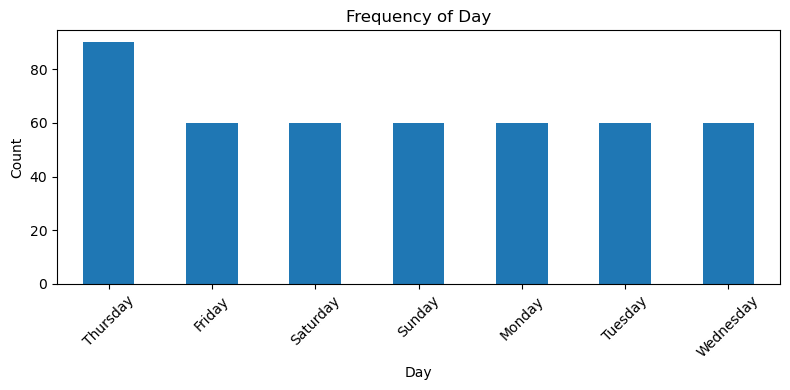

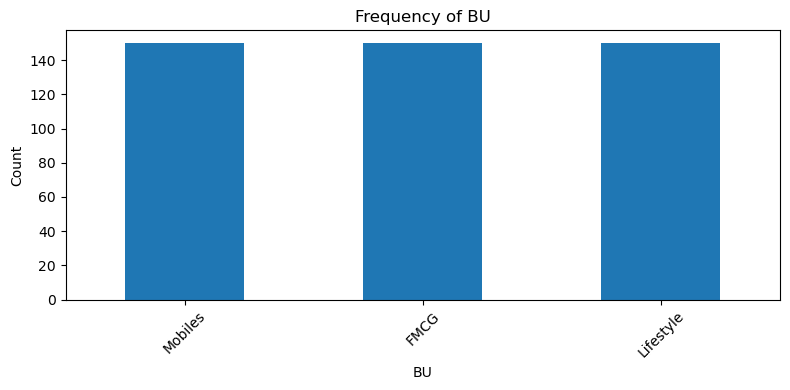

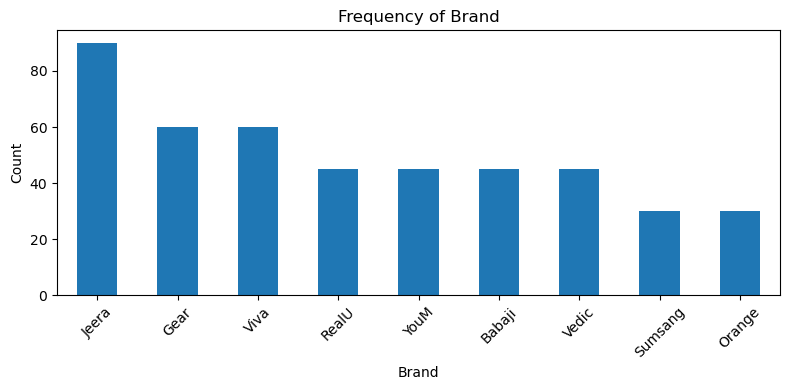

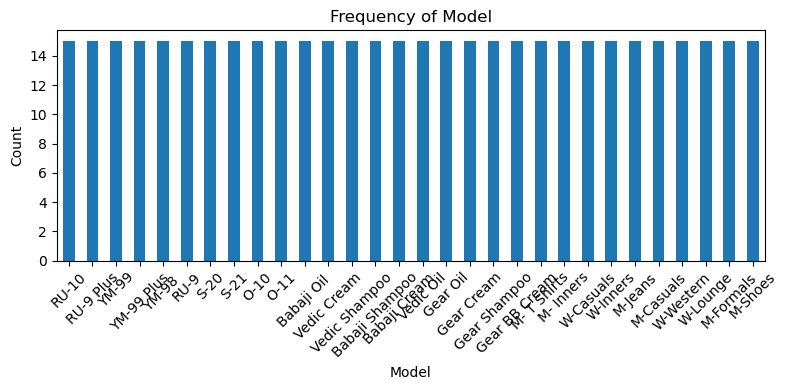

In [52]:
for col in categorical_df.columns:
    categorical_df[col].value_counts().plot(kind='bar', figsize=(8, 4))
    plt.title(f"Frequency of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Most of the categorical data are perfectly equally distributed. This likely suggests the data has been sampled or this is a designed dataset. 

For instance each of the 30 models has exactly 15 units (30 * 15 = 450 total rows).

Each BU (Mobiles, FMCG and Lifestyle) has exactly 150 records each. 

Each day has 60 records specifically, with the exception of Thursday. However, this does not mean Thursdays were best selling days but rather that this dataset included more Thursdays than other weekdays.

The only notable exception is the Frequency of Brand distribution as it is not perfectly distributed equally amongst all brands. Jeera leads with 90 records, meaning it owns 6 models (90 ÷ 15 per model), while Sumsang and Orange have only 2 models each. Gear and Viva own 4 models each. RealU, YouM, Babaji and Vedic are mid-range with 3 models each.

# Conclusions

**Distribution:** 

Histograms for numerical data (Avg Price, Total Sales Value, Discount Amount, Net Sales Value) have strong positive skews (long right tails), which means a small number of high-value transactions are causing the mean to be so much higher than median. The skew is also explained by the box plots which show that the median value is much closer to the lower quartile range than the upper quartile range.  

Volume is closer to normal distribution but with a handful of extreme outliers. Discount Rate is the only negatively-skewed variable, suggesting large discount rates are more typically applied. However in terms of net discount amount, the values sold are genuinely low.

**Outliers:** 
Boxplots showed significant outliers in all value-based columns, reflecting occasional large transactions. These outliers could be reason behind the strong skews.

**Categorical Data:** The categorical analysis revealed the dataset has been hand picked. Every Business Unit has exactly 150 records and each Model has exactly 15 units. Brand was the only categorical column with genuine variation, reflecting real differences in the number of models per brand (Jeera owning 6 models vs. Gear and Viva with 4 each vs RealU, YouM, Babaji and Vedic with 3 models each vs. Sumsang/Orange with 2 each).